### Data Generation for frustrated lattices (Heisenberg J1-J2 models)
This notebook provides examples and tests for modules `spin_lattices` and `heisenberg_hamiltonians`.

In [1]:
import black
import jupyter_black

jupyter_black.load(
    lab=False,
    line_length=79,
    target_version=black.TargetVersion.PY39,
)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import yaml
from heisenberg_hamiltonians import (
    make_unpacked_configurations,
    HeisenbergJ1J2,
)

from spin_lattices import (
    SpinLattice,
    ChainLattice,
    SquareLattice,
    KagomeLattice,
)

%matplotlib inline

#### Chain Lattice (1dim)

self.number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 924
Ground state energy is -21.5495636698


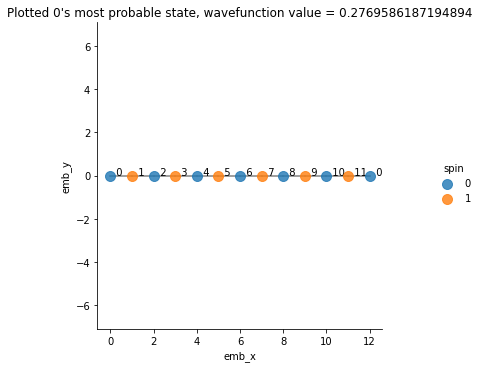

In [3]:
system_nosym = HeisenbergJ1J2(
    ChainLattice(width=12),
    J1=1,
    J2=0,
    use_symmetries=False,
    spin_inversion=None,
)
energy, state = system_nosym.get_ground_state()
system_nosym.visualize_probable_configurations(k=0)

Antiferromagnetic, as expected

self.number_spins=12
Symmetry group contains 24 elements
Hilbert space dimension is 35
Ground state energy is -21.5495636698


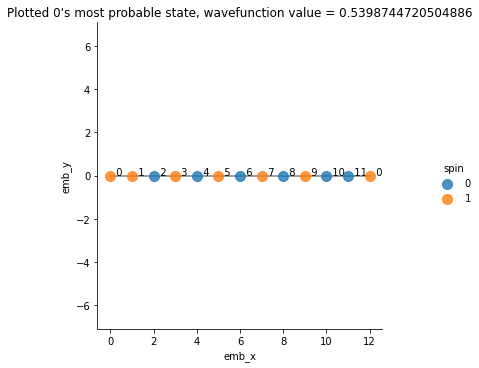

In [4]:
system_sym = HeisenbergJ1J2(
    ChainLattice(width=12), J1=1, J2=0, use_symmetries=True
)
energy, state = system_sym.get_ground_state()
system_sym.visualize_probable_configurations(k=0)

### NB
The “most probable configuration” is not physically defined: we change it when we take symmetries into account (collapse several events into one). So the result is different for calculations with symmetries and without them.

### Checks

#### 4×4 SquareLattice, J2=0

self.number_spins=16
Symmetry group contains 0 elements
Hilbert space dimension is 12870
Ground state energy is -44.9139328337


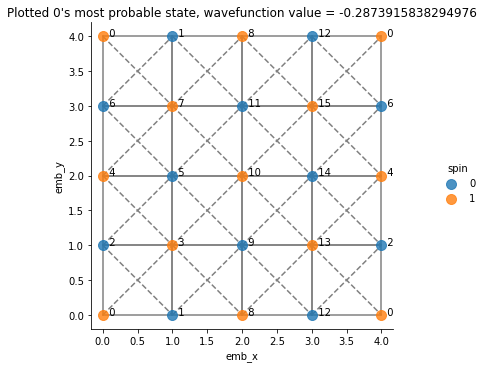

In [5]:
system_nosym = HeisenbergJ1J2(
    SquareLattice(width=4, height=4),
    J1=1,
    J2=0,
    use_symmetries=False,
    spin_inversion=None,
)
system_nosym.get_ground_state()
system_nosym.visualize_probable_configurations(k=0)

The checkerboard, works as expected

self.number_spins=16
Symmetry group contains 128 elements
Hilbert space dimension is 107
Ground state energy is -44.9139328337


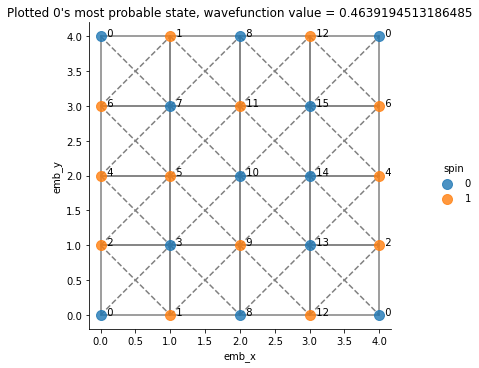

In [6]:
system_sym = HeisenbergJ1J2(
    SquareLattice(width=4, height=4), J1=1, J2=0, use_symmetries=True
)
system_sym.get_ground_state()
system_sym.visualize_probable_configurations(k=0)

In [7]:
# with and without symmetries should give the same ground state energy
assert np.isclose(system_sym.ground_energy, system_nosym.ground_energy)

#### Reference 4×4

In [8]:
### FROM: https://github.com/twesterhout/nqs-playground/blob/0ba67c9d4ff9f70bbaeea2a9490271dd49ea5091/benchmark/benchmark_apply.py#L9-L20
def load_basis_and_hamiltonian(
    filename: str, no_symmetries=False, no_inversions=False
):
    import yaml

    # logger.info("Loading basis from '{}'...", filename)
    with open(filename, "r") as f:
        config = yaml.load(f, Loader=yaml.SafeLoader)
    if no_symmetries:
        config["basis"]["symmetries"] = []
    if no_inversions:
        del config["basis"]["spin_inversion"]
    basis = ls.SpinBasis.load_from_yaml(config["basis"])
    # logger.info("Loading Hamiltonian from '{}'...", filename)
    hamiltonian = ls.Operator.load_from_yaml(config["hamiltonian"], basis)
    return basis, hamiltonian


### END FROM

```
# Initial layout:
    # - permutation: [ 0,  1,  2,  3,
    #                  4,  5,  6,  7,
    #                  8,  9, 10, 11,
    #                 12, 13, 14, 15]
    #
```

In [9]:
basis, hamiltonian = load_basis_and_hamiltonian(
    "heisenberg_square_4x4.yaml", no_symmetries=True, no_inversions=True
)
eigenvalues, eigenstates = ls.diagonalize(hamiltonian, k=1)
assert np.isclose(eigenvalues[0], system_nosym.ground_energy)
# energy coincides with the reference implementation

#### 6×2 lattice 

self.number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 462
Ground state energy is -41.2913023078


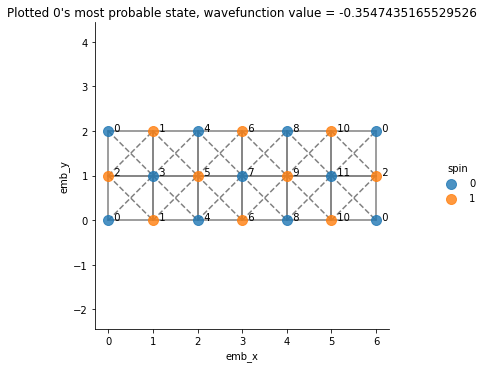

In [10]:
system_nosym = HeisenbergJ1J2(
    SquareLattice(width=6, height=2), J1=1, J2=0, use_symmetries=False
)
system_nosym.get_ground_state()
system_nosym.visualize_probable_configurations(k=0)

The checkerboard, works as expected.

self.number_spins=12
Symmetry group contains 24 elements
Hilbert space dimension is 44
Ground state energy is -41.2913023078


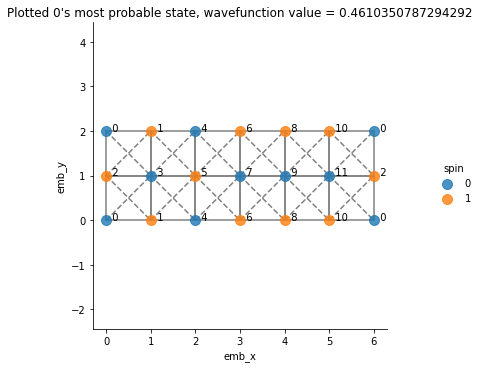

In [11]:
system_sym = HeisenbergJ1J2(
    SquareLattice(width=6, height=2), J1=1, J2=0, use_symmetries=True
)
system_sym.get_ground_state()
system_sym.visualize_probable_configurations(k=0)

### Kagome Lattice

lat.site_to_num.values()=dict_values([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 10, 0, 3, 11, 5, 8, 10, 0])
lat.kind_to_edges=defaultdict(<class 'list'>, {1: [(0, 1), (1, 2), (0, 3), (3, 5), (5, 6), (6, 7), (4, 7), (2, 4), (5, 8), (8, 0), (9, 2), (7, 9), (2, 10), (10, 0), (7, 11), (11, 5)], 2: [(1, 3), (6, 4), (6, 8), (1, 9), (10, 4), (11, 3), (11, 9), (10, 8)]})


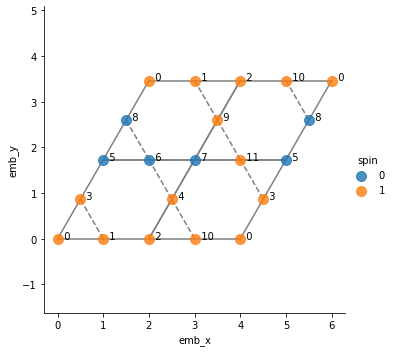

In [12]:
lat = KagomeLattice(width=2, height=2)
lat.plot(spins=np.random.randint(2, size=len(lat.sites)))
assert sorted(set(lat.site_to_num.values())) == list(range(12))
print(f"{lat.site_to_num.values()=}")
print(f"{lat.kind_to_edges=}")
# print(lat.sites_df)

## Canonical basis

In [13]:
system = HeisenbergJ1J2(
    SquareLattice(width=4, height=4),
    J1=1,
    J2=0,
    use_symmetries=True,
    spin_inversion=1,
)
system.get_ground_state()

system_nosym = HeisenbergJ1J2(
    SquareLattice(width=4, height=4),
    J1=1,
    J2=0,
    use_symmetries=False,
    spin_inversion=None,
)
system_nosym.get_ground_state()

self.number_spins=16
Symmetry group contains 128 elements
Hilbert space dimension is 107
Ground state energy is -44.9139328337
self.number_spins=16
Symmetry group contains 0 elements
Hilbert space dimension is 12870
Ground state energy is -44.9139328337


(array([-44.91393283]),
 array([[-0.00075158],
        [-0.00134471],
        [ 0.00087267],
        ...,
        [ 0.00087267],
        [-0.00134471],
        [-0.00075158]]))

Now we compare the results of the diagonalization in the full basis with the restored ground state obtained from the basis where symmetries are taken into account. Note that the ground state is an eigenvector, so it is defined up to multiplication by a constant. We normalize it and make sure it's real, but the constant still can be either 1 or -1. So to check whether two ground states coincide, we first make first element to have the same sign by multiplying one of the vectors on -1 when necessary.

In [14]:
assert (
    system_nosym.get_df_ground_state()
    .merge(
        system.get_df_ground_state(canonical_basis=True),
        on="basis_state",
        how="outer",
    )
    .assign(
        ok=lambda x: np.isclose(
            x["ground_state_coeff_x"],
            x["ground_state_coeff_y"]
            * np.sign(x["ground_state_coeff_y"][0])
            * np.sign(x["ground_state_coeff_x"][0]),
        )
    )["ok"]
    .all()
)

Order of elements in the dataframe correponds to order of elements in basis.states

In [15]:
assert (
    system.get_df_ground_state(canonical_basis=True)["basis_state"]
    == system.canonical_basis.states
).all()

In [16]:
assert (
    system.get_df_ground_state(canonical_basis=False)["basis_state"]
    == system.basis.states
).all()